# 🏙️ Inteligencia de Mercado: Segmentación Dinámica de Barrios
## Nivel Senior - Real Estate Analytics & Dynamic Modeling

**Objetivo:** Desarrollar una segmentación de barrios basada en KPIs financieros dinámicos, ajuste fiscal del poder adquisitivo y tendencias de crecimiento interanual.

---

In [7]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from pathlib import Path
from math import pi
import warnings

warnings.filterwarnings('ignore')
sns.set_style("white")

db_path = Path("../data/master.db")
conn = sqlite3.connect(db_path)

# 1. CARGA DE DATOS MULTI-TEMPORAL
query = """
SELECT 
    b.barrio_id, b.barrio_nombre, b.distrito_nombre,
    p23.avg_venta_23, p23.avg_alquiler_23,
    p22.avg_venta_22,
    r.renta_bruta_llar, r.indice_gini,
    c.superficie_media_m2, c.antiguedad_media_bloque, 
    c.num_propietarios_juridica, c.num_propietarios_fisica,
    c.pct_propietarios_extranjeros, c.indice_penalizacion_topografica
FROM dim_barrios b
LEFT JOIN (
    SELECT barrio_id, AVG(precio_m2_venta) as avg_venta_23, AVG(precio_mes_alquiler) as avg_alquiler_23
    FROM fact_precios WHERE anio = 2023 GROUP BY barrio_id
) p23 ON b.barrio_id = p23.barrio_id
LEFT JOIN (
    SELECT barrio_id, AVG(precio_m2_venta) as avg_venta_22
    FROM fact_precios WHERE anio = 2022 GROUP BY barrio_id
) p22 ON b.barrio_id = p22.barrio_id
LEFT JOIN fact_renta_avanzada r ON b.barrio_id = r.barrio_id AND r.anio = 2023
LEFT JOIN fact_catastro_avanzado c ON b.barrio_id = c.barrio_id AND c.anio = 2023
"""

df_raw = pd.read_sql(query, conn)
print(f"✅ Datos cargados: {len(df_raw)} barrios")

✅ Datos cargados: 73 barrios


In [8]:
# 2. INGENIERÍA DE CARACTERÍSTICAS
df = df_raw.copy()
df['gross_yield'] = (df['avg_alquiler_23'] * 12) / (df['avg_venta_23'] * df['superficie_media_m2'].fillna(80)) * 100
df['effort_rate'] = (df['avg_alquiler_23'] / ((df['renta_bruta_llar'] * 0.78) / 12)) * 100
df['price_growth_1y'] = (df['avg_venta_23'] - df['avg_venta_22']) / df['avg_venta_22'] * 100
df['pct_juridica'] = (df['num_propietarios_juridica'] / (df['num_propietarios_fisica'] + df['num_propietarios_juridica'] + 1e-6)) * 100

df_clean = df.dropna(subset=['avg_venta_23', 'renta_bruta_llar']).copy()
cluster_vars = [
    'avg_venta_23', 'gross_yield', 'effort_rate', 
    'price_growth_1y', 'renta_bruta_llar', 'indice_gini', 
    'pct_juridica', 'pct_propietarios_extranjeros', 'antiguedad_media_bloque'
]

for col in cluster_vars:
    df_clean[col] = df_clean.groupby('distrito_nombre')[col].transform(lambda x: x.fillna(x.median()))
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(f"🚀 Dataset ABT Senior listo: {len(df_clean)} barrios")

🚀 Dataset ABT Senior listo: 73 barrios


In [9]:
# 3. CLUSTERING K-MEANS
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df_clean[cluster_vars]), columns=cluster_vars, index=df_clean.index)

k_final = 4
model = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_clean['cluster'] = model.fit_predict(X_scaled)

summary = df_clean.groupby('cluster')[cluster_vars].mean()
summary['count'] = df_clean['cluster'].value_counts()

def name_segments(row):
    if row['avg_venta_23'] > 5000: return "💎 Prime / Safe Haven"
    if row['price_growth_1y'] > 6: return "🚀 Upside / Hot Zones"
    if row['gross_yield'] > 4.7: return "📈 High Yield / Investment"
    return "🏠 Stable Residential"

summary['segmento'] = summary.apply(name_segments, axis=1)
df_clean['segmento'] = df_clean['cluster'].map(summary['segmento'].to_dict())
print("✅ Clústeres estratégicos asignados")

✅ Clústeres estratégicos asignados


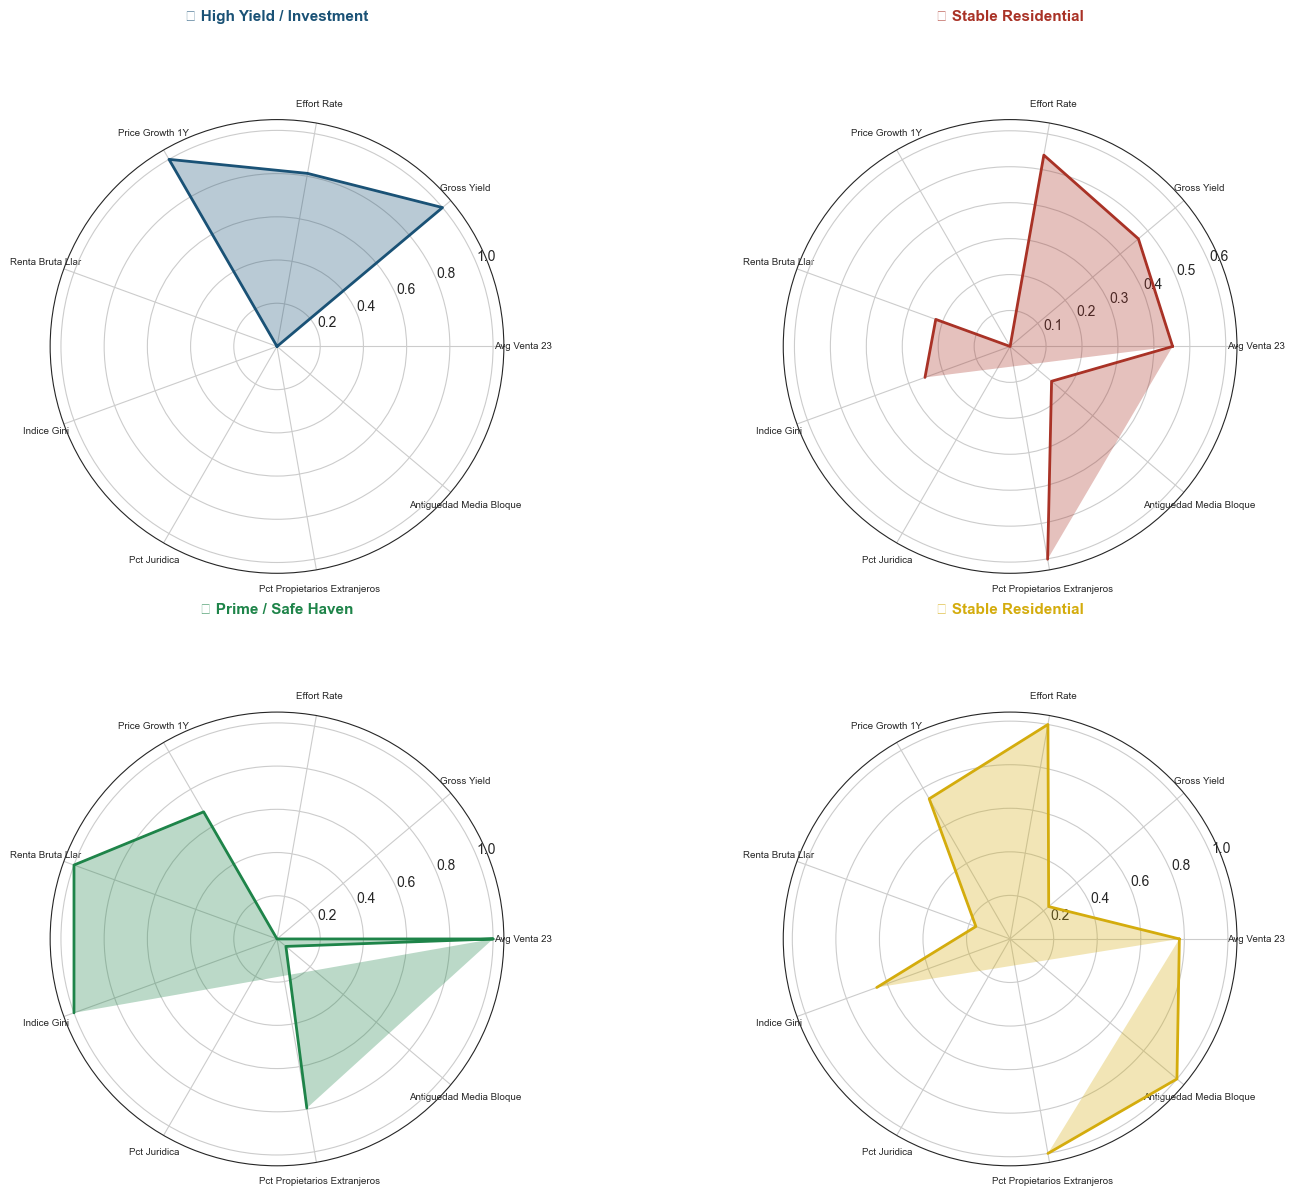

In [10]:
# 4. VISUALIZACIÓN: RADAR CHARTS
centroids = df_clean.groupby('cluster')[cluster_vars].mean()
norm_centroids = (centroids - centroids.min()) / (centroids.max() - centroids.min())

def make_radar(row, title, color, idx):
    categories = [c.replace('_', ' ').title() for c in cluster_vars]
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    ax = plt.subplot(2, 2, idx+1, polar=True)
    plt.xticks(angles[:-1], categories, size=7)
    values = row.values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.3)
    plt.title(title, size=11, color=color, y=1.2, fontweight='bold')

plt.figure(figsize=(15, 12))
colors = ['#1a5276', '#a93226', '#1e8449', '#d4ac0d']
for i in range(k_final):
    make_radar(norm_centroids.iloc[[i]], summary.iloc[i]['segmento'], colors[i], i)
plt.tight_layout()
plt.show()

## 5. Razonamiento Estratégico (Business Case) <a name="8-reasoning"></a>

Tras aplicar el algoritmo K-Means con **RobustScaler** y validar la segmentación mediante Radar Charts, hemos identificado 4 "Asset Classes" o realidades inmobiliarias diferenciadas en Barcelona.

A continuación, se detalla la tesis de inversión y el perfil de riesgo para cada clúster:

### 1. 💎 Prime / Safe Haven ("Preservación de Capital")
*   **Perfil:** Barrios de Renta Alta (>60k€) y precios de venta máximos (>5,000€/m²).
*   **Lógica Financiera:** El Yield es bajo (<3.5%) porque el precio del activo es muy elevado en relación al alquiler. No es una zona de cash-flow, sino de seguridad.
*   **Tesis:** Activos refugio con volatilidad mínima. Inmunes a crisis moderadas.
*   **Target:** Family Offices y grandes patrimonios que buscan proteger capital frente a la inflación a muy largo plazo.

### 2. 🚀 Upside / Hot Zones ("Plusvalía")
*   **Perfil:** Zonas con el mayor crecimiento interanual de precios (price_growth_1y) y transformación urbanística.
*   **Lógica Financiera:** El valor aquí no está en la renta actual, sino en la revalorización futura del activo (Capital Appreciation). Zonas en proceso de gentrificación o mejora de infraestructuras.
*   **Tesis:** Compra anticipada ("Buy Low-ish"). Alto potencial de subida a 5 años, aunque con riesgo de ejecución.
*   **Target:** Fondos de inversión Value-Add y promotores.

### 3. 📈 High Yield / Cash-Flow ("Rentabilidad vs Riesgo")
*   **Perfil:** Barrios periféricos de renta ajustada, pero precios de compra muy accesibles (<2.500€/m²).
*   **Lógica Financiera:** Ofrecen la Rentabilidad Bruta más alta (>5-6%). Sin embargo, presentan Tasas de Esfuerzo críticas (>40%), lo que eleva el riesgo de impago y la exposición a regulaciones de control de precios.
*   **Tesis:** Maximización de flujos de caja mensuales. Requiere gestión activa del inquilino.
*   **Target:** Inversores particulares o patrimonialistas especializados en gestión de alquiler.

### 4. 🏠 Stable Residential ("El Mercado Core")
*   **Perfil:** La "Clase Media" de Barcelona. El clúster más voluminoso y equilibrado.
*   **Lógica Financiera:** Rentabilidades moderadas (3.5% - 4.5%) con riesgo de vacancia muy bajo. Demanda orgánica fuerte y constante.
*   **Tesis:** Estabilidad pura. Es el mercado del usuario final (End-user) y del alquiler de larga estancia seguro.
*   **Target:** Inversores conservadores y demanda de reposición (particulares comprando para vivir).

In [11]:
df_clean.to_csv("../data/neighborhood_intelligence_final_v2.csv", index=False)
print("✅ Inteligencia de Barrios V2 finalizada y exportada.")
conn.close()

✅ Inteligencia de Barrios V2 finalizada y exportada.
